# Notes for Deep Learning with PyTorch Chapter 08
> "Using convolutions to generalize : Understanding convolution; Building a convolutional neural network; Creating custom nn.Module subclasses; The difference between the module and functional APIs; Design choices for neural networks"

- toc: false
- badges: true
- comments: true
- categories: [image recognition, CIFAR-10]
- image: images/dlwpt-screenshots/dlwpt-08-logo.png

## Chapter Contents
- [8.1. the case for convolutions](#8.1.)
    - [8.1.1. what convolutions do](#8.1.1.)
- [8.2. convolutions in action](#8.2.)
    - [8.2.1. padding the boundary](#8.2.1.)
    - [8.2.2. detecting features with convolutions](#8.2.2.)
    - [8.2.3. looking further with depth and pooling](#8.2.3.)
    - [8.2.4. putting it all together for our network](#8.2.4.)
- [8.3. subclassing nn.Module](#8.3.)
    - [8.2.1. out network as an nn.Module](#8.3.1.)
    - [8.2.2. how PyTorch keeps track of parameters and submodules](#8.3.2.)
    - [8.2.3. the functional API](#8.3.3.)
- [8.4. training our convnet](#8.4.)
    - [8.2.1. measuring accuracy](#8.4.1.)
    - [8.2.2. saving and loading our model](#8.4.2.)
    - [8.2.3. training on the gpu](#8.4.3.)
- [8.5. model design](#8.5.)
    - [8.2.1. adding memory capacity](#8.5.1.)
    - [8.2.2. helping our model to converge and generalize: regularization](#8.5.2.)
    - [8.2.3. going deeper to learn more complex structure: depth](#8.5.3.)
    - [8.2.4. comparing the designs from this section](#8.5.4.)
    - [8.2.5. it's already outdated](#8.5.5.)
- [8.6. conclusion](#8.6.)
- [8.7. exercise](#8.7.)

## Summary
- Convolution can be used as the linear operation of a feed-forward network dealing with images. Using convolution produces networks with fewer parameters, exploiting locality and featuring translation invariance.
- Stacking multiple convolutions with their activations one after the other, and using max pooling in between, has the effect of applying convolutions to increasingly smaller feature images, thereby effectively accounting for spatial relationships across larger portions of the input image as depth increases.
- Any nn.Module subclass can recursively collect and return its and its children’s parameters. This technique can be used to count them, feed them into the optimizer, or inspect their values.
- The functional API provides modules that do not depend on storing internal state. It is used for operations that do not hold parameters and, hence, are not trained.
- Once trained, parameters of a model can be saved to disk and loaded back in with one line of code each.

#### Setup and import data

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import collections

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.set_printoptions(edgeitems=2)
torch.manual_seed(123)

In [2]:
connected_model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.Tanh(),
            nn.Linear(1024, 512),
            nn.Tanh(),
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 2))

In [3]:
numel_list = [p.numel()
              for p in connected_model.parameters()
              if p.requires_grad == True]
sum(numel_list), numel_list

(3737474, [3145728, 1024, 524288, 512, 65536, 128, 256, 2])

In [4]:
first_model = nn.Sequential(
                nn.Linear(3072, 512),
                nn.Tanh(),
                nn.Linear(512, 2),
                nn.LogSoftmax(dim=1))

In [5]:
numel_list = [p.numel() for p in first_model.parameters()]
sum(numel_list), numel_list

(1574402, [1572864, 512, 1024, 2])

In [6]:
linear = nn.Linear(3072, 1024)

linear.weight.shape, linear.bias.shape

(torch.Size([1024, 3072]), torch.Size([1024]))

In [7]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

<a id="8.1."></a>
## 8.1. the case for convolutions

<a id="Something"></a>
## 8.1. Something

- to recognize patterns corresponding to objects, we likely need to look at how nearby pixels are arranged
- i.e. less interested in how pixels that are far from each other appear in combination
    - it doesn’t matter if our image of a Spitfire has a tree or cloud or kite in the corner or not
- mathematically speaking, compute weighted sum of a pixel with its immediate neighbors, rather than with all other pixels in the image
- equivalent to building weight matrices, one per output feature and output pixel location, in which all weights beyond a certain distance from a center pixel are zero
- this will still be a weighted sum: that is, a linear operation

<a id="8.1.X."></a>
### 8.1.1. what convolutions do

#### translation invariance
- desirable property that localized patterns have an effect on the output regardless of their location in image
- there are various kinds of invariance:

![](../images/dlwpt-screenshots/dlwpt-08-invariance.png)

#### what is the problem that convolution solves? 
(difficult to go into specifics, but intuitively, just know that:)
- we need to build a weight matrix for every feature AND output pixel location
- this must work even if the image is translated (moved) around in the image
- convolutions solve the problem by 

##### for a one-channel image and 3x3 kernel

![](../images/dlwpt-screenshots/dlwpt-08-01.png)

- note: like nn.Linear, the weights in the kernel are not known in advance, but they are initialized randomly and updated through backpropagation. 
- Note also that the same kernel, and thus each weight in the kernel, is reused across the whole image. Thinking back to autograd, this means the use of each weight has a history spanning the entire image. 
- Thus, the derivative of the loss with respect to a convolution weight includes contributions from the entire image.

<a id="8.2."></a>
## 8.2. convolutions in action

The torch.nn module provides convolutions for 1, 2, and 3 dimensions: 
- `nn.Conv1d` for time series
- `nn.Conv2d` for images
- `nn.Conv3d` for volumes or videos.

##### set up the CIFAR data

In [8]:
!jupyter nbextension enable --py widgetsnbextension

Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK


In [9]:
from torchvision import datasets, transforms
data_path = '../data-unversioned/p1ch6/'
cifar10 = datasets.CIFAR10(
    data_path, train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

Extracting ../data-unversioned/p1ch6/cifar-10-python.tar.gz to ../data-unversioned/p1ch6/


In [10]:
cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

Files already downloaded and verified


In [11]:
label_map = {0: 0, 2: 1}
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label])
          for img, label in cifar10
          if label in [0, 2]]
cifar2_val = [(img, label_map[label])
              for img, label in cifar10_val
              if label in [0, 2]]

In [12]:
conv = nn.Conv2d(3, 16, kernel_size=3) 
# <1> Instead of the shortcut kernel_size=3, we could equivalently pass in the tuple that we
# see in the output: kernel_size=(3, 3). Because fundamentally, kernals are square.
conv

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))

In [13]:
conv.weight.shape, conv.bias.shape

(torch.Size([16, 3, 3, 3]), torch.Size([16]))

- we can see how convolutions are a convenient choice for learning from images. We have smaller models looking for local patterns whose weights are optimized across the entire image.

In [14]:
img, _ = cifar2[0]
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 30, 30]))

- as usual, we need to add the zeroth batch dimension with unsqueeze if we want to call the conv module with one input image, since nn.Conv2d expects a B × C × H × W shaped tensor as input

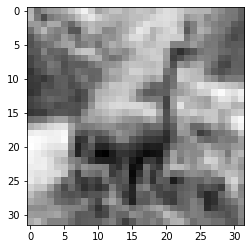

In [15]:
plt.imshow(img.mean(0), cmap='gray')
plt.show()

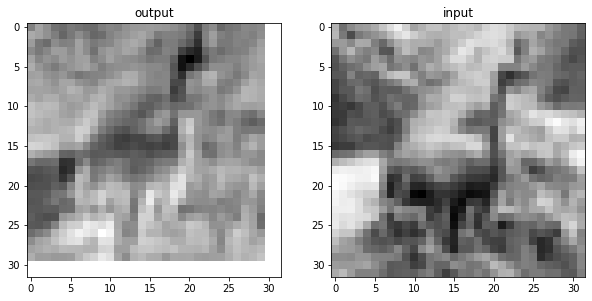

In [16]:
plt.figure(figsize=(10, 4.8))  # bookskip
ax1 = plt.subplot(1, 2, 1)   # bookskip
plt.title('output')   # bookskip
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)  # bookskip
plt.imshow(img.mean(0), cmap='gray')  # bookskip
plt.title('input')  # bookskip
# plt.savefig('Ch8_F2_PyTorch.png')  # bookskip
plt.show()

<a id="8.2.1."></a>
### 8.2.1. padding the boundary

In [17]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1) # <1> now with padding
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 1, 32, 32]))

![](../images/dlwpt-screenshots/dlwpt-08-03.png)

##### padding
- creating ghost pixels around the border that have value zero as far as the convolution is concerned
- means the cell (0,0) has an extra set of neighbors above it and to its left, so that an output of the convolution can be computed even in the corner of our original image
- final net result is that the output has now the exact same size as the input
    - note! padding=1 preserves image size for the case of a 3x3 kernel, i.e. padding and kernel proportionality
    - note! even-sized kernels need to be pad by different numbers on left vs right, top vs bottom
    - note! weight and bias matrix size does not change
- why do we do this?
    - separates the matters of convolution and changing image sizes
    - allows more elaborate structures such as skip connections or U-Nets

<a id="8.2S.2."></a>
### 8.2.2. detecting features with convolutions

In [18]:
with torch.no_grad():
    conv.bias.zero_()  # zero out biases
    
with torch.no_grad():
    conv.weight.fill_(1.0 / 9.0) # sets weight to constant value of 0.1111

- We could have gone with conv.weight.one_() —that would result in each pixel in the output being the sum of the pixels in the neighborhood. Not a big difference, except that the values in the output image would have been nine times larger
????

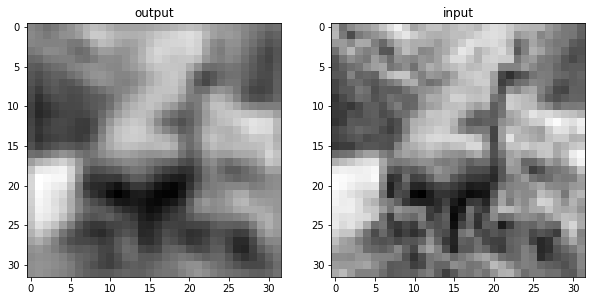

In [19]:
output = conv(img.unsqueeze(0))
plt.figure(figsize=(10, 4.8))  # bookskip
ax1 = plt.subplot(1, 2, 1)   # bookskip
plt.title('output')   # bookskip
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)  # bookskip
plt.imshow(img.mean(0), cmap='gray')  # bookskip
plt.title('input')  # bookskip
# plt.savefig('Ch8_F4_PyTorch.png')  # bookskip
plt.show()

- as expected, produces blurred version of image

In [20]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1)

with torch.no_grad():
    conv.weight[:] = torch.tensor([[-1.0, 0.0, 1.0],
                                   [-1.0, 0.0, 1.0],
                                   [-1.0, 0.0, 1.0]])
    # this kernel may look a bit mysterious at first...
    conv.bias.zero_()

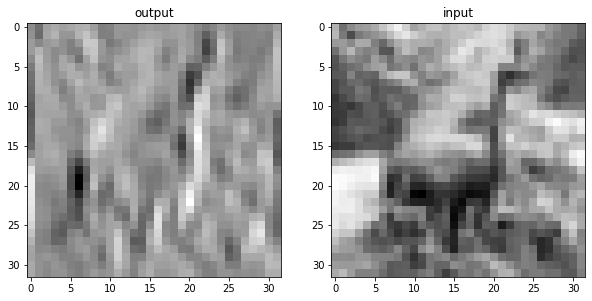

In [21]:
output = conv(img.unsqueeze(0))
plt.figure(figsize=(10, 4.8))  # bookskip
ax1 = plt.subplot(1, 2, 1)   # bookskip
plt.title('output')   # bookskip
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)  # bookskip
plt.imshow(img.mean(0), cmap='gray')  # bookskip
plt.title('input')  # bookskip
# plt.savefig('Ch8_F5_PyTorch.png')  # bookskip
plt.show()

- the difference of all pixels on the right of input (2,2) minus the pixels on the left of input (2,2). If the kernel is applied on a vertical boundary between two adjacent regions of different intensity, output(2,2) will have a high value. 
- If the kernel is applied on a region of uniform intensity, output (2, 2) will be zero. 
- It’s an **edge-detection kernel**: the kernel highlights the vertical edge between two horizontally adjacent regions
- historically, the job of a computer vision expert has historically been to come up with the most effective combination of filters so that certain features are highlighted in images and objects can be recognized

![](../images/dlwpt-screenshots/dlwpt-08-06.png)

<a id="8.2.3."></a>
### 8.2.3. looking further with depth and pooling

#### problem
- what about the big picture? 
- can we use a 32x32 kernel for a 32x32 image? -- no, the point of convolution is lost
- solution: downsampling!

#### from large to small: downsampling
many different ways of doing it:
- Average the four pixels. This average pooling was a common approach early on but has fallen out of favor somewhat.
- Take the maximum of the four pixels. This approach, called max pooling, is currently the most commonly used approach, but it has a downside of discarding the other three-quarters of the data.
- Perform a strided convolution, where only every Nth pixel is calculated. A 3 × 4 convolution with stride 2 still incorporates input from all pixels from the previous layer. The literature shows promise for this approach, but it has not yet supplanted max pooling.

#### Fun Fact: Jeffrey Hinton said -- 
> "The pooling operation used in convolutional neural networks is a big mistake, and the fact that it works so well is a disaster."
- See [this blog](https://towardsdatascience.com/what-is-wrong-with-convolutional-neural-networks-75c2ba8fbd6f) for a tldr

![](../images/dlwpt-screenshots/dlwpt-08-07.png)

In [22]:
pool = nn.MaxPool2d(2)
output = pool(img.unsqueeze(0))

img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 3, 16, 16]))

#### combining convolutions and downsampling for great goood

![](../images/dlwpt-screenshots/dlwpt-08-08.png)

<a id="8.2.4."></a>
### 8.2.4. putting it all together for our network

In [23]:
model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            # ...
            )

In [24]:
model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            # ... <1> warning: something is missing here!
            nn.Linear(8 * 8 * 8, 32),
            nn.Tanh(),
            nn.Linear(32, 2))

![](../images/dlwpt-screenshots/dlwpt-08-09.png)

In [25]:
# 3, 16, kernel_size=3
3 * 16 * 3 * 3
# in channel is the amount of kernels we have in the first model

432

In [26]:
numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

In [27]:
model(img.unsqueeze(0))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x8 and 512x32)

The error is because we are missing a reshaping step from an 8-channel 8 × 8 image to a 512-element, 1D vector (1D if we ignore the batch dimension, that is). We could potentially do this by calling view on the output of the last nn.MaxPool2d , but unfortunately, we don’t have any explicit visibility of the output of each module when we use nn.Sequential... Hence the next section!

<a id="8.3."></a>
## 8.3. subclassing nn.Module

##### why do we need to subclass `nn.Module`?
- pre-made modules offer a lot of convenience
- however, they may not offer computing functionality for everything we want
    - in the case of this example, "reshaping" was not provided with `nn.Sequential`
        - it seems weird that such basic functionality is not included, but it apparently is a deliberate design choice, for which reasons are not exactly known, see this [Github issue](https://github.com/pytorch/pytorch/issues/2486) for more details
- for those not already familiar with Object-Oriented Programming (OOP), subclassing is basically allowing us to custom build our own neural network module based on a basic model

##### components of subclassing `nn.Module`
- at minimum, `forward` (input -> module -> output) must be defined
    - why no `backward` you ask? because with PyTorch, autograd takes care of it automatically, there is never a need to define it!
- submodules
    - define them in constructor `__init__`
    - assigned for use in `forward`
    - holds their parameters throughout lifetime of module
    - must call `super().__init__()` before you can do that

<a id="8.3.1."></a>
### 8.3.1. our network as an nn.Module

In [31]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.act2 = nn.Tanh()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.pool2(self.act2(self.conv2(out)))
        out = out.view(-1, 8 * 8 * 8) # <1> this reshape is what we were missing earlier
        # - first argument in `out.view()` left as -1 as we do
        # not know how many samples will be in the batch
        out = self.act3(self.fc1(out))
        out = self.fc2(out)
        return out

compare the above to what the book previous did:
passing the various layers as arguments into `nn.Sequential`

In [29]:
model_compare = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            # ... <1> warning: something is missing here!
            nn.Linear(8 * 8 * 8, 32),
            nn.Tanh(),
            nn.Linear(32, 2))

- in terms of what they do, the two architectures above are basically the same as the diagram below (except the part we weren't able to do in `nn.Sequential` with the warning)
- basically, subclassing `nn.Module` allows us to write the forward function explicitly, and we can call on `out.view()` to turn it into a B X N vector

> but! there are some differences aside from what's mentioned. what do you see?

![](../images/dlwpt-screenshots/dlwpt-08-10.png)

##### what is the goal of doing all these?
- in a sense, it's compressing information. think about it this way: all the pixels in an image -> probability of 2 classes
1. this goal is featured in the reduction of intermediate values
    - generally shrinking because...
        - pooling reduces pixels
        - output dimensions are lower than input dimensions in linear layers
    - but this information reduction is slower on deeper networks
1. however, the initial convolution layer sort of maintains ouput size
    - input 27 (3 channel x 3 by 3 kernel) -> output 32 (see below note on Kernel trick)
    - the mapping for each output pixel (considered in isolation) still has approximately as many outputs as inputs

> Kernel trick: predating deep learning... projecting into high-dimensional space and then doing conceptually simpler (than linear) machine learning. The initial increases in the number of channels could be seen as a somewhat similar situation.

<a id="8.3.2."></a>
### 8.3.2. how PyTorch keeps track of parameters and submodules

```python
-----
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        ...
-----
```
- the above code is assigning an instance of `nn.Conv2d` as an attribute of `self`, which is an `nn.Module` by inheritence
- this automatically registers the `nn.Conv2d` as a submodule
> caution: these submodules must be top-level attributes, and not buried inside `list` or `dict` instances, else the optimizer will not be able to locate them and their parameters. if you must use `list` or `dict`, PyTorch provides `nn.ModuleList` and `nn.ModuleDict`

##### what if we want to have different function for prediction
- some models have training methods different than its use, and so the eval mode cannot use `forward`
- in such cases, it will make sense to have something like a separate `predict` method
- however! note that calling this `predict` function means we are not calling the model through `__call__` and will thus be without the convenience of hooks, and without the JIT compiler see the module structure

anyway, we can see that the function `Net` is able to access all parameters among its submodules:

In [30]:
model = Net()

numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

- it does this by recursively calling `parameters()` on them, so it doesn't matter if you submodules are nested (as long they're not hidden in lists or dictionaries)
- in the same vein, the optimizer can access their `grad` attribute as well, which is populated by `autograd`

<a id="8.3.3."></a>
### 8.3.3. the functional API

- we previously talked about how the subclassed version is different from the `nn.Sequential` version
- basically, is it possible for us to just keep layers in the initialization, and move the pooling and activation functions to `forward`?
- yes! because PyTorch has `functional` counterparts for every `nn` module, meaning these "have no internal state", and their output value is 100% decided by the value input
    - e.g. `nn.functional.Linear` (different from `nn.Linear`) 
        - has signature `linear(input, weight, bias=None)`
        - both `weight` and `bias` are arguments to the function
- so we can actually afford to make the code in [#8.3.1.](#8.3.1.) more concise

In [ ]:
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

> Tip: niche functions are kept in `torch.nn.functionl` but the general-purpose scientific functions like `tanh` are kept in top-level `torch` namespace, hence the difference

##### how do we know when to use the modular API or the functinoal API?
- it simply depends on your style and taste, and of course the situation
- the book corrects itself at this point, saying that activation function are not always stateless (see Chapter 15 quantization)

> tip: and while stateless modules such as `nn.HardTanh` or `nn.ReLU` can be declared once and reused several times, sometimes it's better to have separte instances, because tools analyzing your model may trip

##### let's see if our model works...

In [32]:
model = Net()
model(img.unsqueeze(0))

tensor([[-0.1309, -0.1730]], grad_fn=<AddmmBackward>)

it does! yay! and according to the book, we're kinda lucky, because getting the right size for the first linear layer can be frustrating

> story time: famous practitioners put in arbitrary numbers and then rely on error messages from PyTorch to backtrack the correct sizes for their linear layers.

<a id="8.4."></a>
## 8.4. training our convnet

##### loops when training our convnet
two nested loops:
1. outer one over the epochs 
1. inner one of the DataLoader that produces batches from our Dataset

##### tasks in each loop
1. Feed the inputs through the model (the forward pass).
1. Compute the loss (also part of the forward pass).
1. Zero any old gradients.
1. Call loss.backward() to compute the gradients of the loss with respect to all parameters (the backward pass).
1. Have the optimizer take a step in toward lower loss.

in addition, we collect and print som einfo. 

In [33]:
import datetime  # <1>

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):  
        # <2> Our loop over the epochs, numbered from 1 to n_epochs 
        # rather than starting at 0 (less confusing)
        loss_train = 0.0
        for imgs, labels in train_loader:  
            # <3> loops over our dataset in the batches that
            # the data loader creates for us... 
            # by the way, (loaders only need length and next)
            
            outputs = model(imgs)  # <4> feeds a batch
            
            loss = loss_fn(outputs, labels)  # <5> computes loss

            optimizer.zero_grad()  # <6> zeros the prev gradients
            
            loss.backward()  # <7> computers gradients of all params
            
            optimizer.step()  # <8> updates model

            loss_train += loss.item()  # <9> sums te loss
            # note the .item(), which is necessary to escape autograd

        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {}'.format(
                datetime.datetime.now(), epoch,
                loss_train / len(train_loader)))  
                # <10> this division obtains an average loss per batch
                # while we can stick to total loss, this is more intuitive

although it's the same dataset from Chapter 7, our model is now substantially different:
- now a subclass of `nn.Module`
- use of convolutions

> Warning: the cell below will take time to run... possibly 20 minutes or more...

In [34]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)  
# <1> he DataLoader batches up the examples of our cifar2 dataset.
# Shuffling randomizes the order of the examples from the dataset.

model = Net()  #  <2> Instantiates our network …
optimizer = optim.SGD(model.parameters(), lr=1e-2)  
# <3>… the stochastic gradient descent optimizer we have been working with …
loss_fn = nn.CrossEntropyLoss()  #  <4> cross-entropy loss fr chapter 7.10

training_loop(  # <5> calls the training loop we defined
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

2021-08-04 08:26:04.763364 Epoch 1, Training loss 0.6229256983775242
2021-08-04 08:28:10.986510 Epoch 10, Training loss 0.34179836312297046
2021-08-04 08:30:47.447884 Epoch 20, Training loss 0.3036529545191747
2021-08-04 08:33:24.727563 Epoch 30, Training loss 0.2771975542329679
2021-08-04 08:35:42.996774 Epoch 40, Training loss 0.25837487869771425
2021-08-04 08:38:02.058162 Epoch 50, Training loss 0.239559684779234
2021-08-04 08:40:23.001130 Epoch 60, Training loss 0.22272835202088023
2021-08-04 08:42:59.522657 Epoch 70, Training loss 0.20473251643644017
2021-08-04 08:45:33.336925 Epoch 80, Training loss 0.19217874403971774
2021-08-04 08:47:59.856871 Epoch 90, Training loss 0.17609632679611253
2021-08-04 08:50:21.820421 Epoch 100, Training loss 0.16433996811604043


<a id="8.4.1."></a>
### 8.4.1. measuring accuracy

##### why measure accuracy
- okay, a bit of a duh question, but basically, the above training just chucked us training loss, which does not tell us how well the model would do on real-world unseen data
- the next cell is basically the same code as Chapter 07

In [35]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)

def validate(model, train_loader, val_loader):
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0

        with torch.no_grad():  # <1> because gradients unwanted
            for imgs, labels in loader:
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1) # <2> index of most likely predicttion
                total += labels.shape[0]  # <3> counts the number of examples, 
                                          # thus total increases by batch size
                correct += int((predicted == labels).sum())  
                # <4> compares prediction and ground-truth, a hit means +1

        print("Accuracy {}: {:.2f}".format(name , correct / total))

validate(model, train_loader, val_loader)

Accuracy train: 0.93
Accuracy val: 0.88


<a id="8.4.2."></a>
### 8.4.2. saving and loading our model

In [36]:
torch.save(model.state_dict(), data_path + 'birds_vs_airplanes.pt')

what does this save?
- all parameters of `model`
    - weights and biases for the 2 x convolution modules
    - weights and biases for the 2 x linear modules

what this means?
- it doesn't save the architecture
- which means we need to ensure we have the architecture when we laod
- we also need to make sure the architecture hasn't changed

In [37]:
loaded_model = Net()  # <1>
loaded_model.load_state_dict(torch.load(data_path
                                        + 'birds_vs_airplanes.pt'))

<All keys matched successfully>

<a id="8.4.3."></a>
### 8.4.3. training on the gpu

- to train on the GPU, we need to use `.to`
- but `Module.to` and `tensor.to` are different
    - `Module.to` is in-place, i.e. the module instance is modified
    - `tensor.to` is out-of-place, i.e. it returns a new tensor

- the book mentions that the implication is... creating the `Optimizer` after moving the parameters to the appropriate device would be good practice
    - why?

In [38]:
device = (torch.device('cuda') if torch.cuda.is_available()
          else torch.device('cpu'))
print(f"Training on device {device}.")

Training on device cuda.


In [39]:
import datetime

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device) #<1>
            labels = labels.to(device=device) #<1>
            # <1> the above two lines that moves imgs and labels to the device we
            # are training on are the only difference from the previous version
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_train += loss.item()

        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {}'.format(
                datetime.datetime.now(), epoch,
                loss_train / len(train_loader)))

In [40]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)

model = Net().to(device=device)  # <1> 
# Moves our model (all parameters) to the GPU. If you forget to move either the
# model or the inputs to the GPU, you will get errors about tensors not being on the same
# device, because the PyTorch operators do not support mixing GPU and CPU inputs.
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

2021-08-04 09:17:06.327210 Epoch 1, Training loss 0.5752937252734117
2021-08-04 09:17:11.462052 Epoch 10, Training loss 0.33312789934455966
2021-08-04 09:17:19.396209 Epoch 20, Training loss 0.29380036216632577
2021-08-04 09:17:26.549600 Epoch 30, Training loss 0.2672178096547248
2021-08-04 09:17:33.710549 Epoch 40, Training loss 0.24530668793969854
2021-08-04 09:17:40.745806 Epoch 50, Training loss 0.22810635981476232
2021-08-04 09:17:48.109837 Epoch 60, Training loss 0.21178365930630144
2021-08-04 09:17:55.116309 Epoch 70, Training loss 0.19786786064980136
2021-08-04 09:18:02.063532 Epoch 80, Training loss 0.1816923106267194
2021-08-04 09:18:09.068281 Epoch 90, Training loss 0.16865258905917976
2021-08-04 09:18:16.161552 Epoch 100, Training loss 0.1549608109957853


we also need to make the same change to the `validate` function:

In [41]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)
all_acc_dict = collections.OrderedDict()

def validate(model, train_loader, val_loader):
    accdict = {}
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in loader:
                imgs = imgs.to(device=device) # changes
                labels = labels.to(device=device) # changes
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1) # <1>
                total += labels.shape[0]
                correct += int((predicted == labels).sum())

        print("Accuracy {}: {:.2f}".format(name , correct / total))
        accdict[name] = correct / total
    return accdict

all_acc_dict["baseline"] = validate(model, train_loader, val_loader)

Accuracy train: 0.93
Accuracy val: 0.88


- notice that it was faster?
- but caution, PyTorch will attempt to load weights to the same device they were saved from... but we don't necessarily know where we want the weights loaded
- so the easier way is to override device information when loading weights

In [44]:
loaded_model = Net().to(device=device)
loaded_model.load_state_dict(torch.load(data_path
                                        + 'birds_vs_airplanes.pt',
                                        map_location=device)) # overload device!

<All keys matched successfully>

<a id="8.5."></a>
## 8.5. model design

##### so far so good, but what if problems change or get more complicated???
- it's a fact... CIFAR-10 is a really simple problem (small images)
- we might not even work with images the next time
- this section aims to provide conceptual tools so we can read latest research papers and implement them in PyTorch (or read their implementations without passing out)

<a id="8.5.1."></a>
### 8.5.1. adding memory capacity: width

- how many neurons per layer? or,
- how many channels per convolution?

In [43]:
class NetWidth(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(16 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 16 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

> Caution: so if we are changing the width, we need to ensure we also update `forward` to algin with the change in vector lengths

In [45]:
model = NetWidth().to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

validate(model, train_loader, val_loader)

2021-08-04 09:41:54.629765 Epoch 1, Training loss 0.5375376125429846
2021-08-04 09:42:00.627106 Epoch 10, Training loss 0.3130283741055021
2021-08-04 09:42:07.396942 Epoch 20, Training loss 0.2705057171309829
2021-08-04 09:42:14.038989 Epoch 30, Training loss 0.23740466432586596
2021-08-04 09:42:20.784180 Epoch 40, Training loss 0.20701970017639695
2021-08-04 09:42:27.495826 Epoch 50, Training loss 0.18001694944064328
2021-08-04 09:42:34.499538 Epoch 60, Training loss 0.15574609239105205
2021-08-04 09:42:41.165592 Epoch 70, Training loss 0.13326626387276466
2021-08-04 09:42:47.725286 Epoch 80, Training loss 0.11225483967525185
2021-08-04 09:42:52.988445 Epoch 90, Training loss 0.09301863176522741
2021-08-04 09:42:58.010701 Epoch 100, Training loss 0.07609475623507789
Accuracy train: 0.97
Accuracy val: 0.90


{'train': 0.9706, 'val': 0.8965}

##### to avoid hard-coding numbers for width...
- pass a parameter to init and parameterize the width, taking care to also parameterize the call to view in the forward function, like below
- you can then free change the number of channels when you instantiate

In [46]:
class NetWidth(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
                               padding=1)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out


In [47]:
model = NetWidth(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

all_acc_dict["width"] = validate(model, train_loader, val_loader)

2021-08-04 09:43:20.002628 Epoch 1, Training loss 0.5414536853504789
2021-08-04 09:43:24.403205 Epoch 10, Training loss 0.3152081231782391
2021-08-04 09:43:29.505146 Epoch 20, Training loss 0.27323454893698357
2021-08-04 09:43:34.528583 Epoch 30, Training loss 0.2428598590907018
2021-08-04 09:43:39.560101 Epoch 40, Training loss 0.21445575223606864
2021-08-04 09:43:44.582168 Epoch 50, Training loss 0.1876191772567998
2021-08-04 09:43:49.649672 Epoch 60, Training loss 0.16354368180985662
2021-08-04 09:43:54.664166 Epoch 70, Training loss 0.1417428902380026
2021-08-04 09:43:59.627869 Epoch 80, Training loss 0.12126439980640533
2021-08-04 09:44:04.709077 Epoch 90, Training loss 0.10210717172854265
2021-08-04 09:44:10.000759 Epoch 100, Training loss 0.08461425661044136
Accuracy train: 0.96
Accuracy val: 0.89


In [48]:
sum(p.numel() for p in model.parameters())

38386

- high capacity 
    - means the model can handle more variability in inputs
    - but more likely to overfit
- following parts discuss how to control overfitting:

<a id="8.5.2."></a>
### 8.5.2. helping our model to converge and generalize: regularization

training a model has 2 steps
1. optimization: reducing loss
1. generalization: getting model to work on unseen data

mathematical tools aimed at making these two steps easier are sometimes subsumed under the term `regularization`

#### keeping the parameters in check: weight penalties
- limiting how much the training makes the weights grow
- most popular
    - L2 regularization: sum of squares of all weights 
        - (also referred to as weight decay, explain why later)
    - L1 regularization: sum of abs values of all weights
- both types of regularization are scaled by a (small) factor
    - which by the way, is a hyperparameter we call "lambda"

##### why is L2 regularization also called weight decay?
- adding L2 regularization to the loss function is equivalent to decreasing each weight by an amount directly proportional to its current value
    - L2 regularization is w_i ** 2
    - negative gradient of L2 regularization is -2 * w_i
    - factor in the lambda hyperparameter, we get -2 * lambda * w_i
- note! weight decay applies to all parameters, including biases
    - imagine how the whole thing would go wrong if weights are changed by biases aren't changed

##### implementing in PyTorch
- compute loss
- iterate parameters of the model
- sum their squares (L2) or their abs values (L1)
- backpropagate

In [49]:
def training_loop_l2reg(n_epochs, optimizer, model, loss_fn,
                        train_loader):
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device)
            labels = labels.to(device=device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            l2_lambda = 0.001
            l2_norm = sum(p.pow(2.0).sum() 
                          for p in model.parameters())  
            # <1> replace pow(2.0) above with abs() for L1 
            loss = loss + l2_lambda * l2_norm

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_train += loss.item()
        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {}'.format(
                datetime.datetime.now(), epoch,
                loss_train / len(train_loader)))


##### but, turns out we actually don't need to do this
- the SGD optimizer already has a weight_decay parameter that corresponds to 2 * lambda, and directly performs weight decay...
- so better check on what your optimizer already provides

In [50]:
model = Net().to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop_l2reg(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)
all_acc_dict["l2 reg"] = validate(model, train_loader, val_loader)

2021-08-04 10:04:00.724265 Epoch 1, Training loss 0.595948681520049
2021-08-04 10:04:07.786338 Epoch 10, Training loss 0.36763485895979936
2021-08-04 10:04:15.565231 Epoch 20, Training loss 0.32932072166045
2021-08-04 10:04:23.196283 Epoch 30, Training loss 0.30598981336803194
2021-08-04 10:04:30.974388 Epoch 40, Training loss 0.2875192171069467
2021-08-04 10:04:38.780254 Epoch 50, Training loss 0.2713125160165653
2021-08-04 10:04:46.432549 Epoch 60, Training loss 0.2550744546731566
2021-08-04 10:04:54.228590 Epoch 70, Training loss 0.2401539986585356
2021-08-04 10:05:02.081738 Epoch 80, Training loss 0.2274386530184442
2021-08-04 10:05:09.778423 Epoch 90, Training loss 0.21632953538636493
2021-08-04 10:05:17.480294 Epoch 100, Training loss 0.20648514901756482
Accuracy train: 0.92
Accuracy val: 0.90


##### not relying too much on a single input: dropout
- simple idea from Geoff Hinton's group's paper in 2014: ["Dropout: a Simple Way to Prevent Neural Networks from Overfitting"](http://mng.bz/nPMa)
- each iteration, you leave some nodes out, effectively training a smaller and different model
- remember that it was said:
    - small models can't remember too much details
        - so they are kinda weak, but they also can't memorize
    - big models remember a lot of details
        - very powerful, but also tends to memorize
- you can also see it in another viewpoint
    - each dropout augments the dataset by providing a variation

##### implementing dropout 
- adding an nn.Dropout module between the nonlinear activation function and the linear or convolutional module of the subsequent layer
- argument: probability with which inputs will be zeroed out
- In case of convolutions, we’ll use the specialized `nn.Dropout2d` or `nn.Dropout3d`, which zero out entire channels of the input:

In [51]:
class NetDropout(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv1_dropout = nn.Dropout2d(p=0.4)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
                               padding=1)
        self.conv2_dropout = nn.Dropout2d(p=0.4)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = self.conv1_dropout(out)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = self.conv2_dropout(out)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [52]:
model = NetDropout(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)
all_acc_dict["dropout"] = validate(model, train_loader, val_loader)

2021-08-04 10:14:44.459227 Epoch 1, Training loss 0.5745075333649945
2021-08-04 10:14:49.498910 Epoch 10, Training loss 0.3834294927347997
2021-08-04 10:14:55.240514 Epoch 20, Training loss 0.35294307929695035
2021-08-04 10:15:01.205712 Epoch 30, Training loss 0.33054040932351614
2021-08-04 10:15:07.262825 Epoch 40, Training loss 0.3144671125396801
2021-08-04 10:15:13.017501 Epoch 50, Training loss 0.29737268046588655
2021-08-04 10:15:18.611573 Epoch 60, Training loss 0.2810217689746504
2021-08-04 10:15:24.209452 Epoch 70, Training loss 0.2713781724310225
2021-08-04 10:15:29.884571 Epoch 80, Training loss 0.2579690897540682
2021-08-04 10:15:35.521760 Epoch 90, Training loss 0.2519935084281454
2021-08-04 10:15:41.051689 Epoch 100, Training loss 0.24033259272955027
Accuracy train: 0.89
Accuracy val: 0.89


##### but we don't want to have dropout happening when we evaluate or use the trained model!
- and be assured that we will not
- there is a `train` property of the `Dropout` modle
    - PyTorch allows us to switch using `model.train()` and `model.eval()`

#### keeping activations in check: batch normalization
- after dropout, another important paper by Google titled [“Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift”](https://arxiv.org/abs/1502.03167) appeared
- the main idea: rescale the inputs so that minibatches have a certain desirable distribution
    - this helps keep inputs away from the saturated portions of activation functions, which has the problem of killing gradients and slowing training

##### how to use batch normalization?
- provided through the `nn.BatchNorm1D` , `nn.BatchNorm2d` , and `nn.BatchNorm3d` modules, depending on the dimensionality of the input
- given the aim to rescale the inputs of the activations, the natural location is after the linear transformation (convolution, in this case) and the activation, as shown here:

In [53]:
class NetBatchNorm(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv1_batchnorm = nn.BatchNorm2d(num_features=n_chans1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3, 
                               padding=1)
        self.conv2_batchnorm = nn.BatchNorm2d(num_features=n_chans1 // 2)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = self.conv1_batchnorm(self.conv1(x))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = self.conv2_batchnorm(self.conv2(out))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

- similar to dropout, batch normalization behaves different during training and inference
- during inference, we don't want a specific input to have to depend on the statistics of other outputs
- we still need to normalize though, but at fixed normalization parameters
- i.e. when the user runs `model.eval()`, the running estimates of the normalization are frozen and used for normalization
    - and of course unfrozen when we run `model.train()`

In [ ]:
model = NetBatchNorm(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)
all_acc_dict["batch_norm"] = validate(model, train_loader, val_loader)